# Kenya Hotel Recommendation System

## Business Understanding

The goal is easy to state: given what a traveller cares about ie a city, a few
must have amenities, a minimum rating, return the Kenyan hotels that fit best,
each shown with its rating, reviews, photos and amenities.

Two kinds of recommender could do this. Collaborative filtering learns from how
users behave ("people who liked this also liked that"), but it needs a history
of bookings or ratings tied to users, which this project doesn't have.
Content-based filtering works from the items themselves, matching a hotel's own
attributes to what the user asked for, so it runs from day one with no user
history. That's the approach taken here.

A recommendation is doing its job if it:

- respects the hard constraints the user set (city, minimum rating),
- ranks better-matched and higher-quality hotels above the rest, and
- draws from across the catalogue instead of returning the same few famous
  hotels every time.

## Data Understanding

The data was pulled once from the Google Places API and cached to
`data/hotels.json`, so everything from here on runs offline. Each record holds a
hotel's name, address, coordinates, star rating, review count, a few review
snippets, inferred amenities and photo paths.

Before building anything on top of it, it's worth seeing what's actually there:
how the hotels spread across cities, how ratings and review counts are
distributed, and where the gaps are.

In [1]:
import json
from pathlib import Path
from collections import Counter
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True

In [2]:
hotels = json.loads(Path("data/hotels.json").read_text(encoding="utf-8"))
df = pd.DataFrame(hotels)
print(f"{len(df)} hotels, {df.shape[1]} columns")
df.head(3)

240 hotels, 14 columns


,id,name,address,location,rating,review_count,price_level,price_range,website,editorial_summary,amenities,reviews,photos,types
0,ChIJk9QkedUQLxgRMlNslpNw_-I,Decasa Hotel Nairobi,"Upper River Road opposite KCB Bank, Nairobi, K...","{'latitude': -1.2812613, 'longitude': 36.8246231}",4.0,958,NaN,None,http://www.decasahotel.co.ke/,"Simple rooms, some with city views, in a relax...","[spa, restaurant, bar, wifi]","[{'author': 'GATANA MICHEAL', 'rating': 5, 'te...","[photos/ChIJk9QkedUQLxgRMlNslpNw_-I_0.jpg, pho...","[hotel, lodging, point_of_interest, establishm..."
1,ChIJh8NNhioRLxgRHWti8I9e1tw,INKS HOTEL,"Latema Junction, River Rd, Nairobi, Kenya","{'latitude': -1.2815537, 'longitude': 36.8255043}",4.0,804,NaN,None,NaN,Unpretentious budget hotel featuring a bar & a...,"[spa, restaurant, bar, wifi, breakfast]","[{'author': 'Godfrey Simiyu', 'rating': 5, 'te...","[photos/ChIJh8NNhioRLxgRHWti8I9e1tw_0.jpg, pho...","[hotel, bar, tourist_information_center, tour_..."
2,ChIJySRYlTEXLxgRyYEa-VHCDhs,"Hotel Boulevard Nairobi, City Centre CBD","Harry Thuku Rd, Nairobi, Kenya","{'latitude': -1.27518, 'longitude': 36.813444}",4.2,2410,NaN,None,https://www.hotelboulevard.co.ke/,Low-key rooms in a hotel with a garden & tenni...,"[pool, spa, restaurant, bar, breakfast]","[{'author': 'Chemutai Ruto', 'rating': 3, 'tex...","[photos/ChIJySRYlTEXLxgRyYEa-VHCDhs_0.jpg, pho...","[hotel, halal_restaurant, pizza_restaurant, ba..."


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 240 non-null    str    
 1   name               240 non-null    str    
 2   address            240 non-null    str    
 3   location           240 non-null    object 
 4   rating             238 non-null    float64
 5   review_count       240 non-null    int64  
 6   price_level        7 non-null      float64
 7   price_range        0 non-null      object 
 8   website            175 non-null    str    
 9   editorial_summary  240 non-null    str    
 10  amenities          240 non-null    object 
 11  reviews            240 non-null    object 
 12  photos             240 non-null    object 
 13  types              240 non-null    object 
dtypes: float64(2), int64(1), object(6), str(5)
memory usage: 26.4+ KB


### Cities

Google returns each hotel's address as free text, so the city has to be pulled
out of it. The `_detect_city` helper (the same one the recommender uses) scans
the address for a known city name. Some addresses are just a road or a Plus Code
with no town in them, so anything that can't be matched that way falls back to
the nearest known destination using the hotel's coordinates. The two passes
below show how much that fallback recovers, the leftover "Unknown" hotels are
the ones genuinely far from any of the twelve destinations.

Unknown after reading the address : 27
Unknown after coordinate fallback : 0


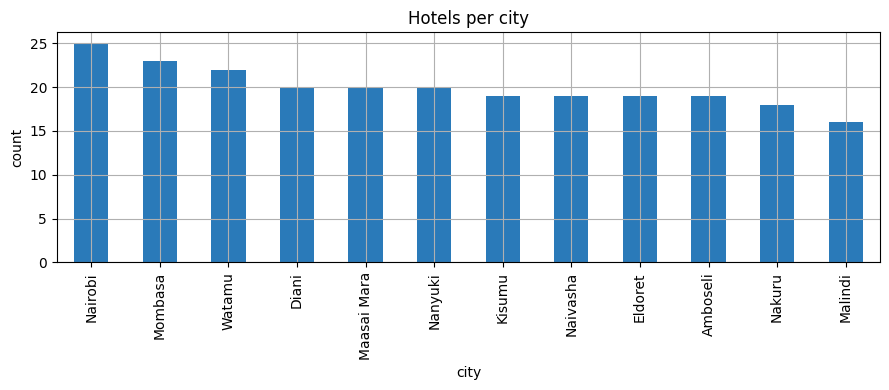

city
Nairobi        25
Mombasa        23
Watamu         22
Diani          20
Maasai Mara    20
Nanyuki        20
Kisumu         19
Naivasha       19
Eldoret        19
Amboseli       19
Nakuru         18
Malindi        16
Name: count, dtype: int64

In [4]:
from recommender import _detect_city, _nearest_city

# Pass 1: read the city straight from the address text.
df["city"] = df["address"].apply(_detect_city)
before = int((df["city"] == "Unknown").sum())

# Pass 2: for anything still unknown, snap to the nearest destination by coords.
unknown = df["city"] == "Unknown"
df.loc[unknown, "city"] = df.loc[unknown, "location"].apply(_nearest_city)
after = int((df["city"] == "Unknown").sum())

print(f"Unknown after reading the address : {before}")
print(f"Unknown after coordinate fallback : {after}")

city_counts = df["city"].value_counts()
city_counts.plot(kind="bar", color="#2a7ab9")
plt.title("Hotels per city")
plt.ylabel("count")
plt.tight_layout()
plt.show()
city_counts

### Ratings

Hotel ratings tend to cluster at the top end. Places that rate badly don't stay
open. So the question is how much spread is left to work with. The wider the
spread, the more rating pulls its weight as a ranking signal.

count    238.000000
mean       4.373529
std        0.331365
min        3.400000
25%        4.100000
50%        4.400000
75%        4.600000
max        5.000000
Name: rating, dtype: float64

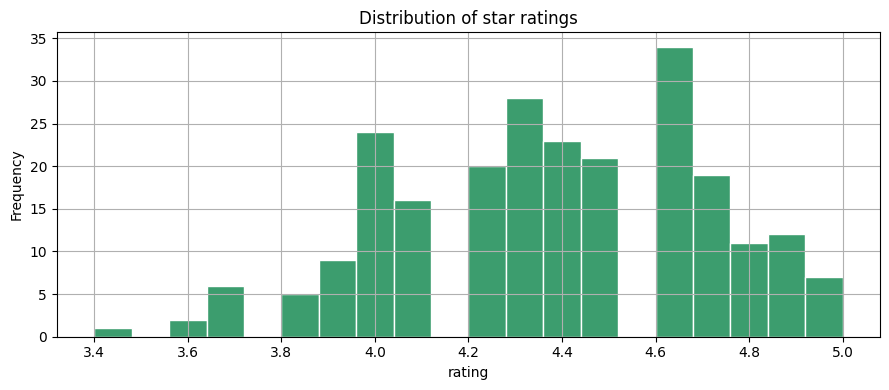

In [5]:
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
display(df["rating"].describe())

df["rating"].plot(kind="hist", bins=20, color="#3c9d6e", edgecolor="white")
plt.title("Distribution of star ratings")
plt.xlabel("rating")
plt.tight_layout()
plt.show()

### Review counts

Review count is a rough stand-in for how established a hotel is. It's heavily
skewed: a few well-known hotels have thousands of reviews while most have far
fewer. A log scale makes that shape readable, and it's the same
`log(1 + reviews)` the recommender uses so a hotel with 3,000 reviews doesn't
completely bury one with 300.

count      240.000000
mean       899.545833
std       1729.322461
min          0.000000
25%         93.500000
50%        303.500000
75%        959.750000
max      17365.000000
Name: review_count, dtype: float64

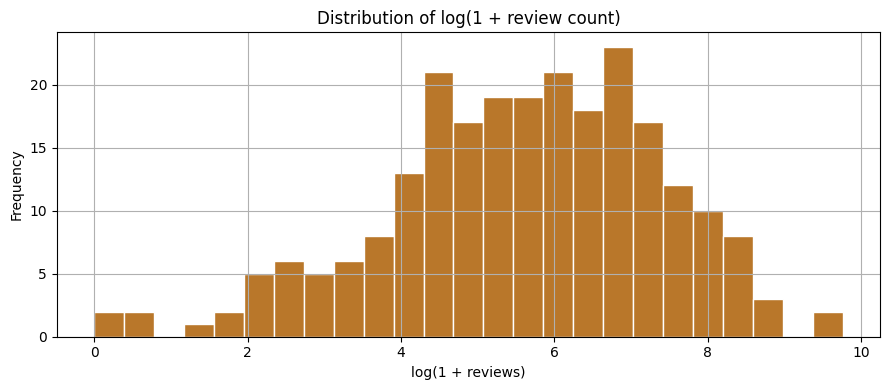

In [6]:
df["review_count"] = pd.to_numeric(df["review_count"], errors="coerce").fillna(0).astype(int)
display(df["review_count"].describe())

np.log1p(df["review_count"]).plot(kind="hist", bins=25, color="#b9772a", edgecolor="white")
plt.title("Distribution of log(1 + review count)")
plt.xlabel("log(1 + reviews)")
plt.tight_layout()
plt.show()

### Price (and why it's dropped)

Price would be an obvious thing to filter on, so the dataset captures Google's
`price_level` field (a 0–4 band) and, on a later pull, the newer `price_range`
field. Both turned out to be almost entirely empty for Kenyan hotels:
`price_range` came back for none of the 240, and `price_level` for only a
handful — all at the same value. The counts below make that plain.

There's no honest way to build a price filter on data this thin, so price is
left out of the model completely. It wasn't one of the original requirements,
and the recommender does its job on amenities, rating and popularity without it.
In production the right fix would be a live pricing API (e.g. Amadeus Hotel
Offers) queried with real check-in and check-out dates.

In [7]:
print("price_level present:", int(df["price_level"].notna().sum()), "of", len(df))
if "price_range" in df.columns:
    print("price_range present:", int(df["price_range"].notna().sum()), "of", len(df))
print()
print(df["price_level"].value_counts(dropna=False))

price_level present: 7 of 240
price_range present: 0 of 240

price_level
NaN    233
2.0      7
Name: count, dtype: int64


### Amenities

Amenities aren't a structured field in the API, so they're inferred by scanning
each hotel's editorial summary and review text for keywords (pool, gym, spa, and
so on). The frequencies matter for matching: a common amenity like a restaurant
says little about a hotel, while a rarer one like an airport shuttle is a much
stronger signal of what a place actually offers.

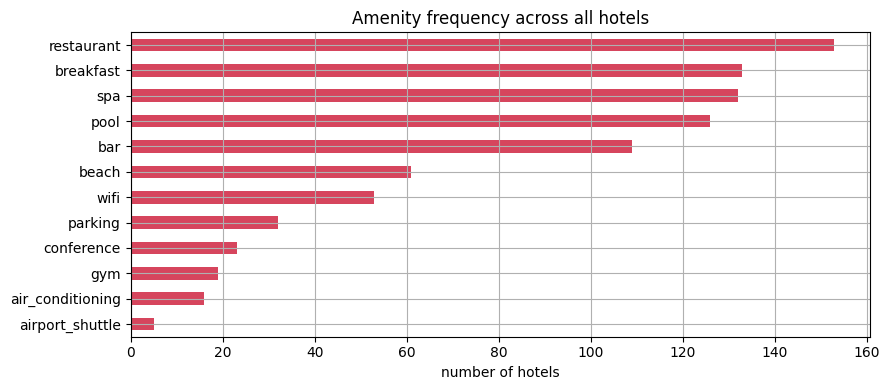

restaurant          153
breakfast           133
spa                 132
pool                126
bar                 109
beach                61
wifi                 53
parking              32
conference           23
gym                  19
air_conditioning     16
airport_shuttle       5
dtype: int64

In [8]:
df["amenities"] = df["amenities"].apply(lambda a: a if isinstance(a, list) else [])
amen_counts = Counter(a for lst in df["amenities"] for a in lst)
amen_series = pd.Series(amen_counts).sort_values(ascending=False)

amen_series.plot(kind="barh", color="#d6455d")
plt.title("Amenity frequency across all hotels")
plt.xlabel("number of hotels")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
amen_series

### Data-quality summary

One table pulling together the gaps found above. This is the go/no-go check: if
something the model relies on were mostly missing, the right move would be to fix
the data pull before modelling, not build on top of it.

In [9]:
report = {
    "hotels total": len(df),
    "rating missing or zero": int((df["rating"].isna() | (df["rating"] == 0)).sum()),
    "price level unknown": int(df["price_level"].isna().sum()),
    "no amenities detected": int(df["amenities"].apply(lambda x: len(x) == 0).sum()),
    "no photos": int(df["photos"].apply(lambda x: len(x or []) == 0).sum()),
    "city = Unknown": int((df["city"] == "Unknown").sum()),
}
pd.Series(report, name="count").to_frame()

,count
hotels total,240
rating missing or zero,2
price level unknown,233
no amenities detected,21
no photos,4
city = Unknown,0


## Data Preparation

The model needs numbers, not raw JSON. Three fields get turned into features,
all handled inside `recommender.py` so the notebook and the deployed app share
exactly the same preparation:

- **Amenities** become a multi-hot vector — a 0/1 across the amenity vocabulary.
  This is what cosine similarity compares.
- **Rating** is scaled to 0–1 (divided by 5).
- **Review count** becomes a 0–1 popularity score via `log(1 + count)`, then
  scaled.

Price was considered and dropped, for the reason shown above.

In [10]:
from recommender import HotelRecommender

rec = HotelRecommender("data/hotels.json")
print("Amenity vocabulary:", rec.vocab)
print("Amenity matrix shape:", rec.amenity_matrix.shape)
print("Full feature matrix shape:", rec.feature_matrix.shape)

# Preview the multi-hot amenity matrix for the first few hotels
pd.DataFrame(rec.amenity_matrix[:5], columns=rec.vocab,
             index=rec.df["name"].head(5)).astype(int)

Amenity vocabulary: ['air_conditioning', 'airport_shuttle', 'bar', 'beach', 'breakfast', 'conference', 'gym', 'parking', 'pool', 'restaurant', 'spa', 'wifi']
Amenity matrix shape: (240, 12)
Full feature matrix shape: (240, 14)


,air_conditioning,airport_shuttle,bar,beach,breakfast,conference,gym,parking,pool,restaurant,spa,wifi
name,,,,,,,,,,,,
Decasa Hotel Nairobi,0,0,1,0,0,0,0,0,0,1,1,1
INKS HOTEL,0,0,1,0,1,0,0,0,0,1,1,1
"Hotel Boulevard Nairobi, City Centre CBD",0,0,1,0,1,0,0,0,1,1,1,0
"Radisson Blu Hotel, Nairobi Upper Hill",0,0,1,0,1,1,0,0,1,1,1,1
The Boma Nairobi,0,0,1,0,1,0,1,0,1,1,1,0


## Modeling

Each hotel gets a score that blends three things:

    score = 0.50 * amenity match   (cosine similarity to the requested amenities)
          + 0.35 * rating          (0–1)
          + 0.15 * popularity      (0–1, from log review count)

Cosine similarity is the heart of it — it measures how well a hotel's amenities
overlap with what the user asked for, regardless of how many amenities either
side happens to list. Rating and popularity sit on top as quality nudges; for
those, higher is simply better, which isn't a similarity question at all. The
hard constraints (city, minimum rating) are applied first as filters, and only
the survivors get scored and ranked.

In [11]:
# Beachfront hotels with a pool in Diani, rated 4.0+
results = rec.recommend(amenities=["pool", "beach"], city="Diani",
                        min_rating=4.0, top_n=5)
pd.DataFrame(results)[["name", "city", "rating", "review_count",
                       "matched_amenities", "score"]]

,name,city,rating,review_count,matched_amenities,score
0,Leopard Beach Resort and Spa,Diani,4.4,1049,"[pool, beach]",0.8231
1,Zarafa House,Diani,4.9,122,"[pool, beach]",0.7705
2,Tombo House,Diani,4.8,107,"[pool, beach]",0.7615
3,Aqua Resort,Diani,4.3,324,"[pool, beach]",0.7434
4,Southern Palms Beach Resort,Diani,4.3,3187,"[pool, beach]",0.7412


In [12]:
# No preferences given — falls back to ranking purely on quality
pd.DataFrame(rec.recommend(top_n=5))[["name", "city", "rating", "review_count", "score"]]

,name,city,rating,review_count,score
0,PrideInn Paradise Beach Resort & Spa Mombasa,Mombasa,4.8,17365,0.9720
1,"Radisson Blu Hotel, Nairobi Upper Hill",Nairobi,4.8,12514,0.9619
2,"Radisson Blu Hotel & Residence, Nairobi Arboretum",Nairobi,4.8,4124,0.9278
3,ibis Styles Nairobi Westlands,Nairobi,4.7,6442,0.9275
4,Lake Naivasha Sopa Resort,Naivasha,4.7,4353,0.9155


### "More like this"

The second mode ignores user preferences and compares hotels to each other,
using cosine similarity over the full feature vectors. It's what you'd put behind
a "similar hotels" strip on a hotel's page.

In [13]:
seed = rec.df.iloc[0]
print("Hotels similar to:", seed["name"], f"({seed['city']})")
pd.DataFrame(rec.similar_to(seed["id"], top_n=5))

Hotels similar to: Decasa Hotel Nairobi (Nairobi)


,id,name,city,rating,similarity
0,ChIJMxjjdlYLOhgRjkFseTygMCs,Kilima Safari Camp,Mombasa,4.2,0.9989
1,ChIJy1FU2kkNOhgRLfoUJ5uimtI,Oilepo Amboseli,Amboseli,4.8,0.9918
2,ChIJh8NNhioRLxgRHWti8I9e1tw,INKS HOTEL,Nairobi,4.0,0.9145
3,ChIJdSOFFlgXKRgRv47IQppSZBc,Mwanzo Lodge,Naivasha,4.3,0.9138
4,ChIJb0mWshWPFRgR-03VMOTuClk,Villa Ameera,Malindi,4.6,0.9079


## Evaluation

There's no record of which hotels users
actually booked or clicked, so there's nothing to score precision or recall
against. Rather than invent an accuracy number, the evaluation leans on two
offline measures alongside the eyeball checks from the previous section.

- **Catalogue coverage** — across a batch of varied queries, how much of the
  catalogue ever gets recommended? Low coverage would mean the system keeps
  funnelling everyone toward the same few hotels.
- **Intra-list diversity** — within one set of results, how different are the
  hotels from each other? It's the average of `1 - cosine similarity` over every
  pair, so higher means more varied.

In [14]:
cities = [c for c in rec.df["city"].unique() if c != "Unknown"]
amenity_combos = [["pool"], ["beach"], ["gym", "spa"],
                  ["restaurant", "bar"], ["wifi", "parking"], []]

recommended = set()
n_queries = 0
for c in cities:
    for ams in amenity_combos:
        n_queries += 1
        for r in rec.recommend(amenities=ams, city=c, top_n=10):
            recommended.add(r["id"])

coverage = len(recommended) / len(rec.df)
print(f"Ran {n_queries} queries across {len(cities)} cities x {len(amenity_combos)} amenity sets")
print(f"Catalogue coverage: {coverage:.1%} "
      f"({len(recommended)} of {len(rec.df)} hotels recommended at least once)")

Ran 72 queries across 12 cities x 6 amenity sets
Catalogue coverage: 86.7% (208 of 240 hotels recommended at least once)


In [15]:
def intra_list_diversity(results):
    idxs = [rec.df.index[rec.df["id"] == r["id"]][0] for r in results]
    vecs = rec.feature_matrix[idxs]
    sims = []
    for a, b in combinations(range(len(vecs)), 2):
        na, nb = np.linalg.norm(vecs[a]), np.linalg.norm(vecs[b])
        if na > 0 and nb > 0:
            sims.append(float(vecs[a] @ vecs[b] / (na * nb)))
    return 1 - np.mean(sims) if sims else 0.0

for ams in [["pool"], ["beach", "spa"], ["wifi"]]:
    res = rec.recommend(amenities=ams, top_n=10)
    print(f"amenities={ams!s:24} intra-list diversity = {intra_list_diversity(res):.3f}")

amenities=['pool']                 intra-list diversity = 0.285
amenities=['beach', 'spa']         intra-list diversity = 0.239
amenities=['wifi']                 intra-list diversity = 0.199


Coverage this high means the recommender is drawing on most of the catalogue
rather than fixating on a few names, and the diversity scores show individual
result lists aren't near-duplicates of one another. Together with the spot-checks
above, that's a fair read on quality given there's no interaction data yet. The
natural next step is to log clicks and bookings once the app is live, then come
back and measure precision properly.

## Deployment

The recommender is validated and lives in an importable module, which makes the
final step straightforward. It happens outside this notebook:

1. **Backend** — a FastAPI service wrapping `recommender.py`, with endpoints that
   return full hotel objects (rating, reviews, photos, amenities).
2. **Frontend** — a page that calls the API and renders hotel cards: photo,
   stars, amenities, reviews.
3. **Hosting** — containerise with Docker, then deploy the backend (Render or
   Railway) and the frontend (Vercel or Netlify).

This notebook stays as the record of why the system is built the way it is; the
running app reuses the very same `recommender.py`.